Задание 1. Анализ выбросов
Постройте **ящики с усами (boxplots)** для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида *Iris virginica* по признаку `sepal width`. Какой процент наблюдений выходит за границы усов?

<details>
<summary>💡 Подсказка</summary>
Используйте `sns.boxplot(x='species', y='sepal width (cm)', data=df)`. Границы усов = Q1 - 1.5×IQR и Q3 + 1.5×IQR.
</details>

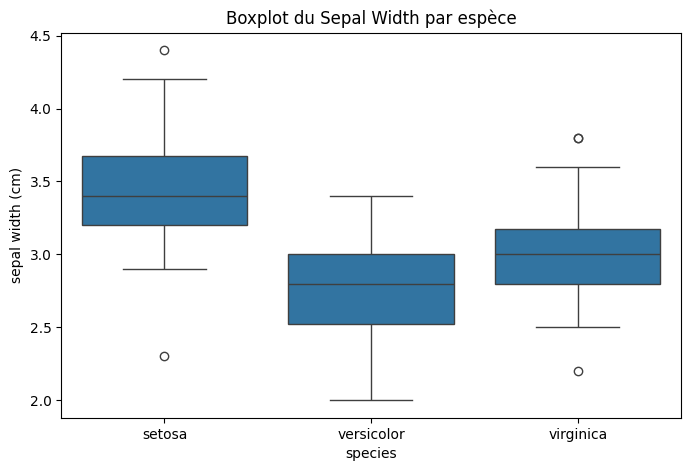

Bornes : 2.237499999999999 3.7375000000000007
Outliers : [3.8 2.2 3.8]
Pourcentage d'outliers : 6.0 %


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement du dataset Iris
df = sns.load_dataset("iris")

# Renommage pour correspondre aux noms du sujet
df = df.rename(columns={
    "sepal_length": "sepal length (cm)",
    "sepal_width": "sepal width (cm)",
    "petal_length": "petal length (cm)",
    "petal_width": "petal width (cm)"
})

# Boxplot pour tous les attributs
plt.figure(figsize=(8,5))
sns.boxplot(x="species", y="sepal width (cm)", data=df)
plt.title("Boxplot du Sepal Width par espèce")
plt.show()

# Détection des outliers pour Iris virginica
virginica = df[df["species"] == "virginica"]["sepal width (cm)"]

Q1 = virginica.quantile(0.25)
Q3 = virginica.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = virginica[(virginica < lower) | (virginica > upper)]
pourcentage = len(outliers) / len(virginica) * 100

print("Bornes :", lower, upper)
print("Outliers :", outliers.values)
print("Pourcentage d'outliers :", round(pourcentage, 2), "%")


Задание 2. Сравнение дисперсий
Рассчитайте **коэффициент вариации** (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

<details>
<summary>💡 Подсказка</summary>
`cv = (df[col].std() / df[col].mean()) * 100`. Высокий CV (>30%) указывает на сильную изменчивость — такие признаки часто требуют масштабирования.
</details>


In [3]:
import seaborn as sns
import pandas as pd

# Chargement du dataset Iris
df = sns.load_dataset("iris")

# Renommage pour correspondre aux noms du sujet
df = df.rename(columns={
    "sepal_length": "sepal length (cm)",
    "sepal_width": "sepal width (cm)",
    "petal_length": "petal length (cm)",
    "petal_width": "petal width (cm)"
})

# Colonnes numériques
cols = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

# Calcul du coefficient de variation
cv = {}
for col in cols:
    cv[col] = (df[col].std() / df[col].mean()) * 100

cv_series = pd.Series(cv).sort_values(ascending=False)
print("Coefficient de variation (%) pour chaque attribut :\n")
print(cv_series)

print("\nAttribut le plus variable :", cv_series.idxmax())


Coefficient de variation (%) pour chaque attribut :

petal width (cm)     63.555114
petal length (cm)    46.974407
sepal width (cm)     14.256420
sepal length (cm)    14.171126
dtype: float64

Attribut le plus variable : petal width (cm)


Задание 3. Создание нового признака
Создайте производный признак **«соотношение длины и ширины лепестка»** (`petal_length / petal_width`). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?

<details>
<summary>💡 Подсказка</summary>
`df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']`. Используйте `sns.violinplot` для сравнения распределений.
</details>

/tmp/ipython-input-547/360802930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="species", y="petal_ratio", data=df, palette="Set2")


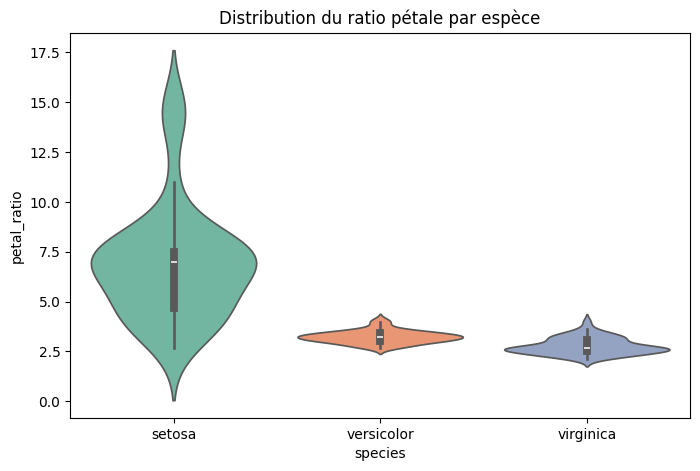

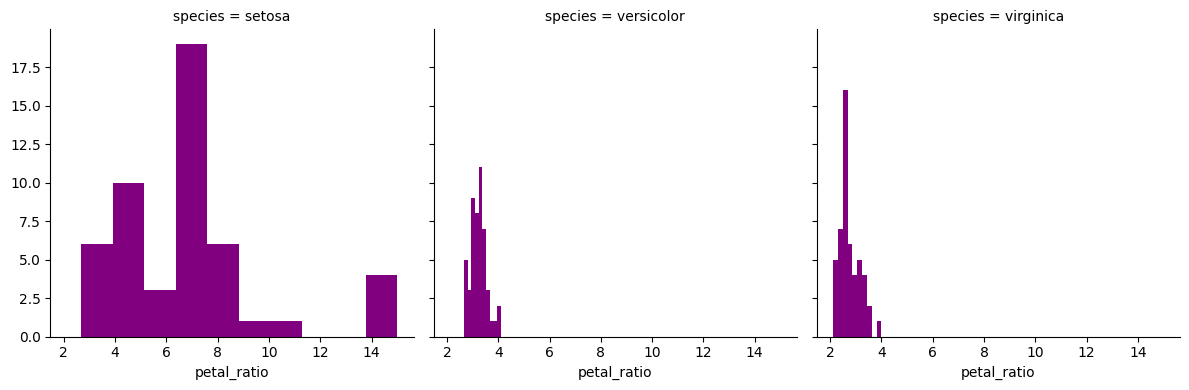

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Création du nouveau trait
df["petal_ratio"] = df["petal length (cm)"] / df["petal width (cm)"]

# Violinplot pour comparer les distributions
plt.figure(figsize=(8,5))
sns.violinplot(x="species", y="petal_ratio", data=df, palette="Set2")
plt.title("Distribution du ratio pétale par espèce")
plt.show()

# Histogrammes par espèce
g = sns.FacetGrid(df, col="species", height=4, aspect=1)
g.map(plt.hist, "petal_ratio", bins=10, color="purple")
plt.show()
